# Experiment: Inspect Trust-me MOMENT Embeddings

This notebook inspects embeddings produced by `trustME_trustme/source/segment_trustme.py`.

It is safe to run **before embeddings are finished**; cells handle missing artifacts gracefully.


In [33]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


In [34]:
# ---- Paths and knobs ----
ROOT = Path('../..')
EMB_DIR = Path(ROOT / 'trustME_trustme/data/processed/trustme_tobii_0shot')
EMB_PATH = EMB_DIR / 'moment_embeddings.npz'
META_PATH = EMB_DIR / 'segments_metadata.parquet'
MANIFEST_PATH = EMB_DIR / 'manifest.json'

# If embeddings are large, inspect only a subset of rows.
MAX_ROWS_FOR_ANALYSIS = 100_000  # set None to use all rows
RANDOM_SEED = 42

EMB_DIR, EMB_PATH.exists(), META_PATH.exists(), MANIFEST_PATH.exists()


(PosixPath('../../trustME_trustme/data/processed/trustme_tobii_0shot'),
 True,
 True,
 True)

In [35]:
if MANIFEST_PATH.exists():
    manifest = json.loads(MANIFEST_PATH.read_text())
    print('Manifest counts:', manifest.get('counts', {}))
    print('Model:', manifest.get('model', {}))
else:
    manifest = {}
    print('manifest.json not found yet.')

if META_PATH.exists():
    metadata = pd.read_parquet(META_PATH)
    print('Metadata shape:', metadata.shape)
    print('Metadata columns:', list(metadata.columns))
else:
    metadata = pd.DataFrame()
    print('segments_metadata.parquet not found yet.')

HAS_EMB = EMB_PATH.exists()
if not HAS_EMB:
    print('moment_embeddings.npz not found yet. Re-run this notebook after embedding job finishes.')


Manifest counts: {'drop_reason_counts': {'low_valid_fraction': 425213, 'too_few_valid_frames': 4}, 'metadata_rows': 118252, 'parquet_files_processed': 65, 'segments_dropped': 425217, 'segments_kept': 118252, 'segments_total_candidates': 543469, 'subjects_processed': 2}
Model: {'batch_size': 64, 'computed_embeddings': True, 'device': 'auto', 'name': 'AutonLab/MOMENT-1-large', 'reduction': 'mean', 'task_name': 'embedding'}
Metadata shape: (118252, 29)
Metadata columns: ['segment_id', 'source_row_idx', 'Subject', 'Path', 'Filename', 'window_id', 'Start_i', 'End_i', 'Start_t', 'End_t', 'Label', 'orig_len', 'valid_fraction', 'max_invalid_run', 'kept', 'drop_reason', 'pad_len', 'sleep_feedback', 'prompt_id', 'prompt_time', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [36]:
if HAS_EMB:
    payload = np.load(EMB_PATH, allow_pickle=False)
    embeddings = payload['embeddings'].astype(np.float32)
    segment_ids = payload['segment_id'].astype(str)
    
    print("File size (MB):", round(EMB_PATH.stat().st_size / (1024 * 1024), 1))
    print('Embeddings shape:', embeddings.shape)
    print('Segment IDs shape:', segment_ids.shape)

    if not metadata.empty:
        kept = metadata.copy()
        if 'segment_id' not in kept.columns:
            raise ValueError('Metadata missing segment_id column.')

        kept = kept.set_index('segment_id', drop=False)
        missing = sorted(set(segment_ids) - set(kept.index.astype(str)))
        if missing:
            raise ValueError(f'Missing metadata rows for {len(missing)} segment_ids. First few: {missing[:5]}')

        aligned_meta = kept.loc[segment_ids].reset_index(drop=True)
        print('Aligned metadata shape:', aligned_meta.shape)
    else:
        aligned_meta = pd.DataFrame({'segment_id': segment_ids})
else:
    embeddings = np.zeros((0, 0), dtype=np.float32)
    segment_ids = np.asarray([], dtype=str)
    aligned_meta = pd.DataFrame()


File size (MB): 428.3
Embeddings shape: (118252, 1024)
Segment IDs shape: (118252,)
Aligned metadata shape: (118252, 29)


In [37]:
if HAS_EMB and embeddings.shape[0] > 0:
    n_total = embeddings.shape[0]
    if MAX_ROWS_FOR_ANALYSIS is None or MAX_ROWS_FOR_ANALYSIS >= n_total:
        idx = np.arange(n_total)
    else:
        rng = np.random.default_rng(RANDOM_SEED)
        idx = np.sort(rng.choice(n_total, size=MAX_ROWS_FOR_ANALYSIS, replace=False))

    X = embeddings[idx]
    meta_sub = aligned_meta.iloc[idx].reset_index(drop=True)

    print(f'Using {len(idx):,}/{n_total:,} rows for analysis')
    print('Embedding dim:', X.shape[1])

    norms = np.linalg.norm(X, axis=1)
    print('Norms: min/mean/max =', round(float(norms.min()), 2), round(float(norms.mean()), 2), round(float(norms.max()), 2))

    if 'Subject' in meta_sub.columns:
        print('Subjects:')
        print(meta_sub['Subject'].value_counts(dropna=False).sort_index())

    if 'sleep_feedback' in meta_sub.columns:
        print('sleep_feedback counts:')
        print(meta_sub['sleep_feedback'].value_counts(dropna=False).sort_index())
else:
    X = np.zeros((0, 0), dtype=np.float32)
    meta_sub = pd.DataFrame()


Using 100,000/118,252 rows for analysis
Embedding dim: 1024
Norms: min/mean/max = 2.48 2.67 2.83
Subjects:
Subject
s_004_pk    46876
s_005_ak    53124
Name: count, dtype: int64
sleep_feedback counts:
sleep_feedback
3.0    24692
4.0    43184
5.0    16822
6.0     6117
NaN     9185
Name: count, dtype: int64


Using random subset of 5000 rows for PCA plot

PCA plot colored by Subject (if available):


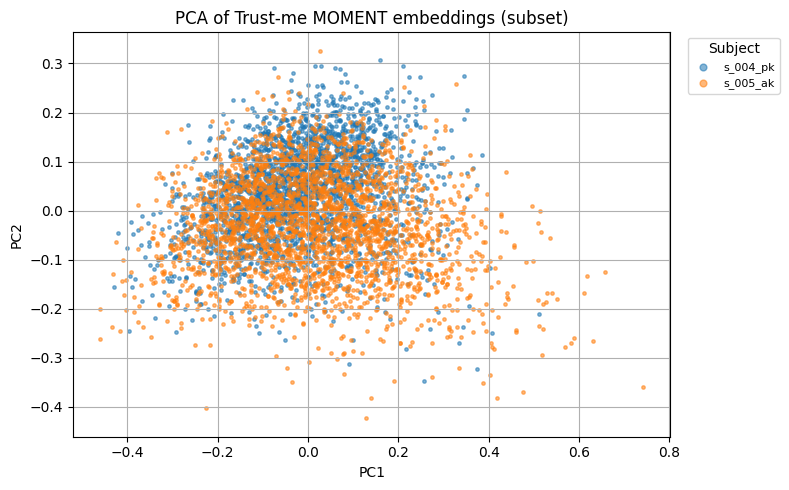


PCA plot colored by sleep_feedback (if available):


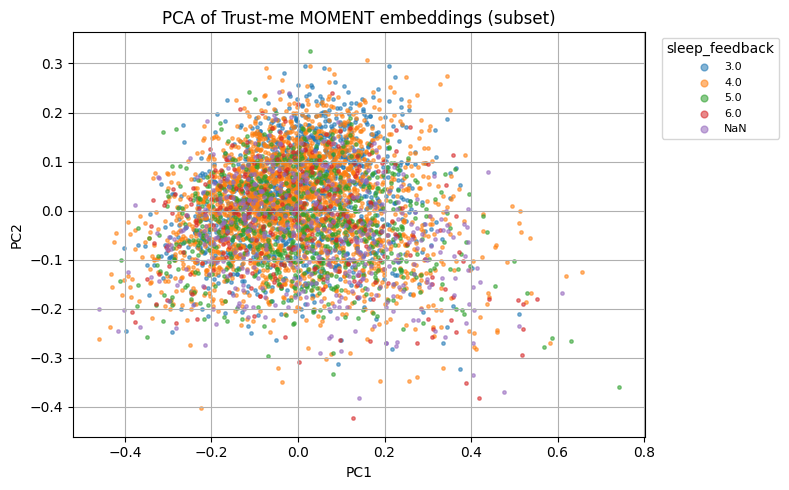

Explained variance ratio: [0.17552704 0.07957838]


In [39]:
RANDOM_SUBSET_SIZE = 5000
if X.shape[0] > RANDOM_SUBSET_SIZE:
    rng = np.random.default_rng(RANDOM_SEED)
    subset_idx = np.sort(rng.choice(X.shape[0], size=RANDOM_SUBSET_SIZE, replace=False))
    X_temp = X[subset_idx]
    meta_sub_temp = meta_sub.iloc[subset_idx].reset_index(drop=True)
    print(f'Using random subset of {RANDOM_SUBSET_SIZE} rows for PCA plot')

if X_temp.shape[0] > 1:
    pca = PCA(n_components=2, random_state=RANDOM_SEED)
    Z = pca.fit_transform(X_temp)

    
    observed_cols = ["Subject", "sleep_feedback"]

    for observed_col in observed_cols:
        print(f'\nPCA plot colored by {observed_col} (if available):')
        fig, ax = plt.subplots()

        if observed_col in meta_sub_temp.columns:
            labels = meta_sub_temp[observed_col].astype('string').fillna('NaN')
            top_labels = labels.value_counts().index[:8]
            label_plot = labels.where(labels.isin(top_labels), other='other')

            for lbl in sorted(label_plot.unique()):
                mask = (label_plot == lbl).to_numpy()
                ax.scatter(Z[mask, 0], Z[mask, 1], s=6, alpha=0.55, label=str(lbl))
            ax.legend(markerscale=2, fontsize=8, title=observed_col, bbox_to_anchor=(1.02, 1), loc='upper left')
        else:
            ax.scatter(Z[:, 0], Z[:, 1], s=6, alpha=0.55)

        ax.set_title('PCA of Trust-me MOMENT embeddings (subset)')
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        plt.tight_layout()
        plt.show()

    print('Explained variance ratio:', pca.explained_variance_ratio_)
else:
    print('Not enough rows to run PCA plot yet.')


## Notes
- `np.load` on compressed `.npz` reads arrays into memory; subseting happens **after** load.
- For very large runs, keep `MAX_ROWS_FOR_ANALYSIS` small and avoid expensive plots.
- Once full embeddings are done, re-run from top to refresh counts and alignment checks.
